In [1]:
import torch
import torch.nn as nn
import torchaudio
import torchaudio.functional as F
import soundfile as sf
import numpy as np
print(torch.__version__)
print(torchaudio.__version__)
import os
import pandas as pd
import matplotlib.pyplot as plt
import librosa
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset, random_split

2.10.0+cu130
2.10.0+cu130


In [2]:

SR = 16000
DURATION = 10
N_MELS = 128
N_FFT = 1024
HOP = 512

In [3]:
def build_mimii_pump_dataframe(root_dir,id):
    records = []
    machine_path= root_dir

    for condition in ["normal", "abnormal"]:
        condition_path = os.path.join(machine_path, condition)

        if not os.path.exists(condition_path):
            continue

        for file in os.listdir(condition_path):
            if file.endswith(".wav"):
                records.append({
                    "machine_id": id,
                    "condition": condition,
                    "file_path": os.path.join(condition_path, file)
                })

    return pd.DataFrame(records)

In [4]:
id="id_06"
root_dir = rf"D:\College\TCG\data\0_dB_pump\pump\{id}"
df = build_mimii_pump_dataframe(root_dir,id)

print(df.head())
print(df["condition"].value_counts())

  machine_id condition                                          file_path
0      id_06    normal  D:\College\TCG\data\0_dB_pump\pump\id_06\norma...
1      id_06    normal  D:\College\TCG\data\0_dB_pump\pump\id_06\norma...
2      id_06    normal  D:\College\TCG\data\0_dB_pump\pump\id_06\norma...
3      id_06    normal  D:\College\TCG\data\0_dB_pump\pump\id_06\norma...
4      id_06    normal  D:\College\TCG\data\0_dB_pump\pump\id_06\norma...
condition
normal      1036
abnormal     102
Name: count, dtype: int64


In [5]:
df["label"] = df["condition"].map({"normal": 0, "abnormal": 1})

In [6]:
normal_df=df[df['condition']=='normal']
abnormal_df = df[df['condition']=='abnormal']
train_df = normal_df.iloc[:int(len(normal_df)*0.7)]
temp_df = pd.concat([normal_df.iloc[int(len(normal_df)*0.7):], abnormal_df])
val_df, test_df   = train_test_split(temp_df, test_size=0.5, shuffle=True)

In [7]:
print("Validation Data:",val_df['condition'].value_counts())
print("Training Data:",train_df['condition'].value_counts())
print("Test Data:",test_df['condition'].value_counts())

Validation Data: condition
normal      143
abnormal     63
Name: count, dtype: int64
Training Data: condition
normal    725
Name: count, dtype: int64
Test Data: condition
normal      168
abnormal     39
Name: count, dtype: int64


In [8]:
y_val = val_df['label'].values
y_test = test_df['label'].values

In [9]:
### Audio preprocessing

def load_logmel(path):
    # Load audio
    waveform, sr = sf.read(path, dtype="float32")  # (T, C) or (T,)

    # Handle channels explicitly
    if waveform.ndim == 2:          # multi-channel (e.g., 8)
        y = waveform.mean(axis=1)   # average across channels
    else:
        y = waveform

    # Resample if needed (CRITICAL)
    if sr != SR:
        y = librosa.resample(y, orig_sr=sr, target_sr=SR)

    # Enforce fixed length
    target_len = SR * DURATION
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    # Compute mel spectrogram
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP,
        n_mels=N_MELS#,power=2.0
    )

    # Log scaling with numerical stability
    logmel = librosa.power_to_db(mel, ref=np.max)

    return logmel.astype(np.float32)

In [10]:
# dt_n=np.load("normal_dataset.npy")
# dt_a=np.load("abnormal_dataset.npy")

In [11]:
# dt_new_n = dt_n.reshape(991, -1)
# dt_new_a = dt_a.reshape(119, -1)
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# scaler = StandardScaler()
# X_scaled_n = scaler.fit_transform(dt_new_n)
# X_scaled_a = scaler.fit_transform(dt_new_a)

In [12]:
# pca_2d = PCA(n_components=3)
# X_vis_n = pca_2d.fit_transform(X_scaled_n)
# X_vis_a = pca_2d.fit_transform(X_scaled_a)

In [13]:
# import matplotlib.pyplot as plt

# plt.scatter(X_vis_n[:, 0], X_vis_n[:, 1])
# plt.scatter(X_vis_a[:, 0], X_vis_a[:, 1])
# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.show()

In [14]:
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D

# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_subplot(111, projection='3d')

# # Normal points
# ax.scatter(
#     X_vis_n[:, 0],
#     X_vis_n[:, 1],
#     X_vis_n[:, 2],
#     c='blue',
#     alpha=0.6,
#     label='Normal'
# )

# # Abnormal points
# ax.scatter(
#     X_vis_a[:, 0],
#     X_vis_a[:, 1],
#     X_vis_a[:, 2],
#     c='red',
#     alpha=0.6,
#     label='Anomaly'
# )

# ax.set_xlabel("PC1")
# ax.set_ylabel("PC2")
# ax.set_zlabel("PC3")

# ax.legend()
# plt.title("3D PCA Visualization")
# plt.tight_layout()
# plt.show()


In [15]:
# import plotly.graph_objects as go

# fig = go.Figure()

# # Normal points
# fig.add_trace(go.Scatter3d(
#     x=X_vis_n[:, 0],
#     y=X_vis_n[:, 1],
#     z=X_vis_n[:, 2],
#     mode='markers',
#     marker=dict(
#         size=4,
#         color='blue',
#         opacity=0.6
#     ),
#     name='Normal'
# ))

# # Abnormal points
# fig.add_trace(go.Scatter3d(
#     x=X_vis_a[:, 0],
#     y=X_vis_a[:, 1],
#     z=X_vis_a[:, 2],
#     mode='markers',
#     marker=dict(
#         size=4,
#         color='red',
#         opacity=0.6
#     ),
#     name='Anomaly'
# ))

# fig.update_layout(
#     title="3D PCA Visualization",
#     scene=dict(
#         xaxis_title='PC1',
#         yaxis_title='PC2',
#         zaxis_title='PC3'
#     ),
#     width=900,
#     height=700
# )

# fig.show()

In [16]:
# np.save("normal_dataset.npy", normal_dataset)
# np.save("abnormal_dataset.npy", abnormal_dataset)


In [17]:
class WindowEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)

In [18]:
class WindowDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1)
        )

    def forward(self, x):
        return self.net(x)


In [19]:
class WindowAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = WindowEncoder()
        self.decoder = WindowDecoder()

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)

        # Safety crop (important)
        recon = recon[:, :, :x.size(2), :x.size(3)]
        return recon


In [20]:
def frame_logmel_2d(logmel, win_frames=64, hop_frames=32):
    """
    logmel: (n_mels, T)
    returns: (n_windows, 1, n_mels, win_frames)
    """
    n_mels, T = logmel.shape
    windows = []

    for start in range(0, T - win_frames + 1, hop_frames):
        w = logmel[:, start:start + win_frames]  # (n_mels, win_frames)
        windows.append(w)

    if len(windows) == 0:
        raise ValueError("Logmel too short")

    windows = np.stack(windows, axis=0)        # (Nw, n_mels, win_frames)
    windows = windows[:, None, :, :]           # (Nw, 1, n_mels, win_frames)
    return windows


In [21]:
def extract_frmed_logmel_with_labels(df, win_frames=64, hop_frames=32):
    X_windows = []
    expanded_labels = []

    for _, row in df.iterrows():
        logmel = load_logmel(row['file_path'])
        windows = frame_logmel_2d(logmel, win_frames=win_frames, hop_frames=hop_frames)
        n_windows = len(windows)
        X_windows.append(windows)
        expanded_labels.extend([row['label']] * n_windows)  

    X = np.concatenate(X_windows, axis=0)
    mu = X.mean(axis=(0, 3), keepdims=True)
    std = X.std(axis=(0, 3), keepdims=True) + 1e-6
    X = (X - mu) / std

    return X, np.array(expanded_labels, dtype=np.float32)

In [22]:
X_train_scaled, y_train_exp = extract_frmed_logmel_with_labels(train_df)
X_val_scaled,   y_val_exp   = extract_frmed_logmel_with_labels(val_df)
X_test_scaled,  y_test_exp  = extract_frmed_logmel_with_labels(test_df)

train_tensor = TensorDataset(
    torch.FloatTensor(X_train_scaled),
    torch.FloatTensor(y_train_exp)
)
val_tensor = TensorDataset(
    torch.FloatTensor(X_val_scaled),
    torch.FloatTensor(y_val_exp)
)
test_tensor = TensorDataset(
    torch.FloatTensor(X_test_scaled),
    torch.FloatTensor(y_test_exp)
)

train_loader = DataLoader(train_tensor, batch_size=64, shuffle=True,  drop_last=True)
test_loader  = DataLoader(test_tensor,  batch_size=64, shuffle=False)
val_loader   = DataLoader(val_tensor,   batch_size=64, shuffle=False)

In [52]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = WindowAutoEncoder().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

EPOCHS = 100
best_val_loss = float("inf")
best_weights = None

for epoch in range(EPOCHS):
    # ---------- TRAIN ----------
    model.train()
    train_loss = 0.0

    for batch, _ in train_loader:
        batch = batch.to(device)

        optimizer.zero_grad()
        recon = model(batch)
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch.size(0)

    train_loss /= len(train_loader.dataset)

    # ---------- VALIDATION ----------
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch, _ in val_loader:
            batch = batch.to(device)
            recon = model(batch)
            loss = criterion(recon, batch)
            val_loss += loss.item() * batch.size(0)

    val_loss /= len(val_loader.dataset)

    # ---------- CHECKPOINT ----------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # ---------- LOG ----------
    if (epoch+1) % 10 == 0:
        print(
            f"Epoch {(epoch+1):03d} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Best Val: {best_val_loss:.6f}"
        )

# Restore best weights after training
model.load_state_dict(best_weights)
print(f"\nRestored best weights (val loss: {best_val_loss:.6f})")

Epoch 010 | Train Loss: 0.297157 | Val Loss: 0.297578 | Best Val: 0.297578
Epoch 020 | Train Loss: 0.271779 | Val Loss: 0.290277 | Best Val: 0.276237
Epoch 030 | Train Loss: 0.249394 | Val Loss: 0.264564 | Best Val: 0.254231
Epoch 040 | Train Loss: 0.234201 | Val Loss: 0.231488 | Best Val: 0.231488
Epoch 050 | Train Loss: 0.221100 | Val Loss: 0.225362 | Best Val: 0.221249
Epoch 060 | Train Loss: 0.211487 | Val Loss: 0.211304 | Best Val: 0.211304
Epoch 070 | Train Loss: 0.205791 | Val Loss: 0.205663 | Best Val: 0.204397
Epoch 080 | Train Loss: 0.201147 | Val Loss: 0.202968 | Best Val: 0.198144
Epoch 090 | Train Loss: 0.187858 | Val Loss: 0.192999 | Best Val: 0.192421
Epoch 100 | Train Loss: 0.175662 | Val Loss: 0.188712 | Best Val: 0.178752

Restored best weights (val loss: 0.178752)


In [53]:
torch.save(model.state_dict(), f"best_AE_model_{id}.pth")

In [54]:
#model=torch.load(rf'D:\College\TCG\Baseline_MIMII Systems\pump\best_AE_model_{id}.pth', weights_only=True)

Val  — AUC: 0.7400  |  pAUC (FPR≤0.1): 0.5776
Test — AUC: 0.6952  |  pAUC (FPR≤0.1): 0.5930


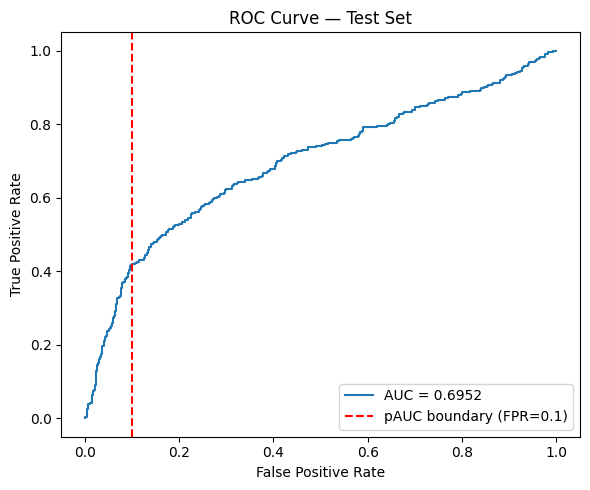

In [55]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

def get_anomaly_scores(loader, model, criterion, device):
    """Returns (scores, labels) arrays — one entry per window."""
    model.eval()
    all_scores = []
    all_labels = []

    with torch.no_grad():
        for batch, labels in loader:
            batch = batch.to(device)
            recon = model(batch)

            # Per-sample MSE (mean over all dims except batch)
            errors = ((recon - batch) ** 2).mean(dim=[1, 2, 3])

            all_scores.append(errors.cpu().numpy())
            all_labels.append(labels.numpy())

    return np.concatenate(all_scores), np.concatenate(all_labels)


# --- Compute scores ---
val_scores,  val_labels  = get_anomaly_scores(val_loader,  model, criterion, device)
test_scores, test_labels = get_anomaly_scores(test_loader, model, criterion, device)

# --- ROC-AUC ---
val_auc  = roc_auc_score(val_labels,  val_scores)
test_auc = roc_auc_score(test_labels, test_scores)

# --- pAUC (partial AUC) — DCASE standard: FPR in [0, 0.1] ---
# max_fpr=0.1 restricts to the low-FPR region, then sklearn normalises to [0,1]
val_pauc  = roc_auc_score(val_labels,  val_scores,  max_fpr=0.1)
test_pauc = roc_auc_score(test_labels, test_scores, max_fpr=0.1)



print(f"Val  — AUC: {val_auc:.4f}  |  pAUC (FPR≤0.1): {val_pauc:.4f}")
print(f"Test — AUC: {test_auc:.4f}  |  pAUC (FPR≤0.1): {test_pauc:.4f}")

# --- Plot ROC curve ---
fpr, tpr, _ = roc_curve(test_labels, test_scores)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
plt.axvline(x=0.1, color="red", linestyle="--", label="pAUC boundary (FPR=0.1)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Test Set")
plt.legend()
plt.tight_layout()
plt.show()